# 03 - Robustness Experiments

## Reliable Machine-Failure Prediction Under Imbalanced and Corrupted Sensor Data

The clean-data baseline experiments showed that an unweighted Random Forest
with a decision threshold of 0.20 provided the strongest failure-detection
performance.

This notebook investigates whether that prediction system remains reliable
when realistic data-quality and data-availability problems are introduced.

The following robustness conditions are studied:

1. Sensor measurement noise
2. Missing sensor measurements
3. Limited training data

Performance under each condition will be compared with the clean-data
reference results.

### Clean-data reference

- Accuracy: 97.27%
- Precision: 56.76%
- Recall: 82.35%
- F1-score: 67.20%
- Average Precision: 78.03%

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

RANDOM_STATE = 42

project_root = Path.cwd().parent

print("Project root:", project_root)

Project root: c:\Users\aacaa\Documents\reliable-machine-failure-prediction


In [2]:
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Source path:", src_path)

Source path: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\src


In [3]:
from data_loader import (
    load_ai4i_data,
    create_model_data
)

from preprocessing import create_preprocessor

print("Project functions imported successfully.")

Project functions imported successfully.


In [4]:
data = load_ai4i_data()

print("Dataset shape:", data.shape)

display(data.head())

Dataset shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
X, y = create_model_data(data)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (10000, 6)
Target shape: (10000,)

Features:
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temporary, y_train, y_temporary = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data equally
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temporary,
    y_temporary,
    test_size=0.50,
    random_state=42,
    stratify=y_temporary
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("\nFailure counts:")
print("Training:", y_train.sum())
print("Validation:", y_validation.sum())
print("Test:", y_test.sum())


Training shape: (7000, 6)
Validation shape: (1500, 6)
Test shape: (1500, 6)

Failure counts:
Training: 237
Validation: 51
Test: 51


## 2. Recreate the Random Forest Preprocessing

The selected Random Forest model must receive data in the same form used
during the baseline experiments.

For the tree-based model, numerical sensor values are kept on their original
scale, while categorical information is encoded numerically.

The preprocessing pipeline is fitted only on the training data and then
applied unchanged to the validation and test sets.

This prevents data leakage and ensures that the robustness experiments use
the same preprocessing procedure as the original baseline model.

In [7]:
tree_preprocessor = create_preprocessor(
    scale_numeric=False
)

print(tree_preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Air temperature', 'Process temperature',
                                  'Rotational speed', 'Torque', 'Tool wear']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Type'])])


In [8]:
X_train_tree = tree_preprocessor.fit_transform(
    X_train
)

X_validation_tree = tree_preprocessor.transform(
    X_validation
)

X_test_tree = tree_preprocessor.transform(
    X_test
)

print("Training transformed shape:", X_train_tree.shape)
print("Validation transformed shape:", X_validation_tree.shape)
print("Test transformed shape:", X_test_tree.shape)

Training transformed shape: (7000, 8)
Validation transformed shape: (1500, 8)
Test transformed shape: (1500, 8)


## 3. Recreate the Selected Random Forest

The baseline experiments identified the unweighted Random Forest as the
selected model for machine-failure prediction.

The same model configuration is recreated here so that the robustness
experiments use the exact same prediction system as the clean-data baseline.

The model is trained only on the training data. Its configuration is kept
fixed throughout the robustness experiments so that later performance
changes can be attributed to data corruption rather than changes in the model.

In [9]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tree,
    y_train
)

print("Selected Random Forest trained successfully.")

Selected Random Forest trained successfully.


## 4. Use the Selected Decision Threshold

The Random Forest outputs a probability of machine failure.

During the baseline experiments, the validation set was used to select a
decision threshold of 0.20 instead of the default threshold of 0.50.

This threshold is kept fixed during the robustness experiments.

Keeping the threshold unchanged allows us to measure how the already-selected
prediction system behaves when data quality becomes worse.

In [10]:
selected_threshold = 0.20

print("Selected decision threshold:", selected_threshold)

Selected decision threshold: 0.2


## 5. Verify the Clean-Data Reference

Before introducing sensor noise, missing measurements, or limited training
data, the reconstructed Random Forest is evaluated on the untouched clean
test set.

The obtained results should match the final clean-data results from the
baseline notebook.

If they match, it confirms that the same data split, preprocessing, model,
and decision threshold have been reproduced correctly.

In [11]:
clean_probabilities = random_forest_model.predict_proba(
    X_test_tree
)[:, 1]

clean_predictions = (
    clean_probabilities >= selected_threshold
).astype(int)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

clean_precision = precision_score(
    y_test,
    clean_predictions,
    zero_division=0
)

clean_recall = recall_score(
    y_test,
    clean_predictions
)

clean_f1 = f1_score(
    y_test,
    clean_predictions
)

clean_ap = average_precision_score(
    y_test,
    clean_probabilities
)

clean_matrix = confusion_matrix(
    y_test,
    clean_predictions
)

clean_reference = pd.DataFrame(
    {
        "Accuracy": [clean_accuracy],
        "Precision": [clean_precision],
        "Recall": [clean_recall],
        "F1-score": [clean_f1],
        "Average precision": [clean_ap],
        "Threshold": [selected_threshold]
    },
    index=["Clean reference"]
)

print("Clean-data reference results:")
display(clean_reference.round(4))

print("\nClean-data confusion matrix:")
print(clean_matrix)

Clean-data reference results:


,Accuracy,Precision,Recall,F1-score,Average precision,Threshold
Clean reference,0.9727,0.5676,0.8235,0.672,0.7803,0.2



Clean-data confusion matrix:
[[1417   32]
 [   9   42]]


## 6. Experiment 1 - Sensor Measurement Noise

Real industrial sensors do not always produce perfectly accurate measurements.

Temperature, torque, rotational speed, and other measurements may contain
small errors because of sensor limitations, vibration, electrical noise,
calibration errors, or environmental conditions.

In this experiment, controlled random noise is added to the numerical sensor
features in the test set.

The trained Random Forest model and the decision threshold of 0.20 are kept
unchanged.

The purpose of this experiment is to measure how prediction performance
changes as sensor measurements become increasingly noisy.

In [12]:
numeric_sensor_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

print("Numerical sensor features:")

for feature in numeric_sensor_features:
    print("-", feature)

Numerical sensor features:
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear


In [13]:
def add_sensor_noise(
    X_data,
    noise_level,
    numeric_features,
    random_state=RANDOM_STATE
):
    noisy_data = X_data.copy()

    rng = np.random.default_rng(random_state)

    for feature in numeric_features:
        feature_std = X_data[feature].std()

        noise_std = noise_level * feature_std

        noise = rng.normal(
            loc=0.0,
            scale=noise_std,
            size=len(X_data)
        )

        noisy_data[feature] = (
            X_data[feature] + noise
        )

    return noisy_data


print("Sensor-noise function created successfully.")

Sensor-noise function created successfully.


In [14]:
X_test_noise_10 = add_sensor_noise(
    X_test,
    noise_level=0.10,
    numeric_features=numeric_sensor_features,
    random_state=RANDOM_STATE
)

print("10% noise test set created successfully.")

10% noise test set created successfully.


In [15]:
comparison = pd.DataFrame({
    "Clean Air temperature": X_test["Air temperature"].head(5).values,
    "Noisy Air temperature": X_test_noise_10["Air temperature"].head(5).values,

    "Clean Rotational speed": X_test["Rotational speed"].head(5).values,
    "Noisy Rotational speed": X_test_noise_10["Rotational speed"].head(5).values,

    "Clean Torque": X_test["Torque"].head(5).values,
    "Noisy Torque": X_test_noise_10["Torque"].head(5).values
})

display(comparison.round(3))

,Clean Air temperature,Noisy Air temperature,Clean Rotational speed,Noisy Rotational speed,Clean Torque,Noisy Torque
0,298.1,298.160,1557,1578.456,36.0,34.552
1,297.7,297.495,1559,1570.814,35.2,36.257
2,301.5,301.648,1549,1582.775,38.5,37.227
3,298.0,298.186,1462,1435.410,48.2,48.976
4,298.3,297.915,1708,1703.442,28.0,27.318


In [16]:
X_test_noise_10_tree = tree_preprocessor.transform(
    X_test_noise_10
)

print(
    "Noisy test transformed shape:",
    X_test_noise_10_tree.shape
)

Noisy test transformed shape: (1500, 8)


In [17]:
noise_10_probabilities = random_forest_model.predict_proba(
    X_test_noise_10_tree
)[:, 1]

noise_10_predictions = (
    noise_10_probabilities >= selected_threshold
).astype(int)

noise_10_accuracy = accuracy_score(
    y_test,
    noise_10_predictions
)

noise_10_precision = precision_score(
    y_test,
    noise_10_predictions,
    zero_division=0
)

noise_10_recall = recall_score(
    y_test,
    noise_10_predictions
)

noise_10_f1 = f1_score(
    y_test,
    noise_10_predictions
)

noise_10_ap = average_precision_score(
    y_test,
    noise_10_probabilities
)

noise_10_matrix = confusion_matrix(
    y_test,
    noise_10_predictions
)

print("10% sensor-noise results:")
print("Accuracy:", round(noise_10_accuracy, 4))
print("Precision:", round(noise_10_precision, 4))
print("Recall:", round(noise_10_recall, 4))
print("F1-score:", round(noise_10_f1, 4))
print("Average precision:", round(noise_10_ap, 4))

print("\nConfusion matrix:")
print(noise_10_matrix)

10% sensor-noise results:
Accuracy: 0.9633
Precision: 0.4744
Recall: 0.7255
F1-score: 0.5736
Average precision: 0.6605

Confusion matrix:
[[1408   41]
 [  14   37]]


In [18]:
clean_vs_noise_10 = pd.DataFrame(
    {
        "Accuracy": [
            clean_accuracy,
            noise_10_accuracy
        ],
        "Precision": [
            clean_precision,
            noise_10_precision
        ],
        "Recall": [
            clean_recall,
            noise_10_recall
        ],
        "F1-score": [
            clean_f1,
            noise_10_f1
        ],
        "Average precision": [
            clean_ap,
            noise_10_ap
        ]
    },
    index=[
        "Clean",
        "10% noise"
    ]
)

display(clean_vs_noise_10.round(4))

,Accuracy,Precision,Recall,F1-score,Average precision
Clean,0.9727,0.5676,0.8235,0.6720,0.7803
10% noise,0.9633,0.4744,0.7255,0.5736,0.6605


In [19]:
performance_drop_10 = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "Average precision"
        ],
        "Clean": [
            clean_accuracy,
            clean_precision,
            clean_recall,
            clean_f1,
            clean_ap
        ],
        "10% noise": [
            noise_10_accuracy,
            noise_10_precision,
            noise_10_recall,
            noise_10_f1,
            noise_10_ap
        ]
    }
)

performance_drop_10["Absolute change"] = (
    performance_drop_10["10% noise"]
    - performance_drop_10["Clean"]
)

performance_drop_10["Percentage-point change"] = (
    performance_drop_10["Absolute change"] * 100
)

display(performance_drop_10.round(4))

,Metric,Clean,10% noise,Absolute change,Percentage-point change
0,Accuracy,0.9727,0.9633,-0.0093,-0.9333
1,Precision,0.5676,0.4744,-0.0932,-9.3209
2,Recall,0.8235,0.7255,-0.0980,-9.8039
3,F1-score,0.6720,0.5736,-0.0984,-9.8357
4,Average precision,0.7803,0.6605,-0.1198,-11.9830


### Multiple Sensor-Noise Levels

To evaluate robustness systematically, the selected Random Forest is tested
under several sensor-noise levels.

The same test samples, preprocessing pipeline, trained model, target labels,
and decision threshold are kept fixed.

Only the amount of simulated noise in the numerical sensor measurements is
changed.

This allows the relationship between sensor-noise severity and prediction
performance to be measured directly.

In [20]:
noise_levels = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]

noise_results = []

for noise_level in noise_levels:

    # Create noisy copy of the test set
    X_noisy = add_sensor_noise(
        X_test,
        noise_level=noise_level,
        numeric_features=numeric_sensor_features,
        random_state=RANDOM_STATE
    )

    # Apply the already-fitted preprocessing
    X_noisy_tree = tree_preprocessor.transform(
        X_noisy
    )

    # Get failure probabilities
    probabilities = random_forest_model.predict_proba(
        X_noisy_tree
    )[:, 1]

    # Apply the fixed threshold
    predictions = (
        probabilities >= selected_threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    ap = average_precision_score(
        y_test,
        probabilities
    )

    noise_results.append(
        {
            "Noise level": noise_level,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Average precision": ap
        }
    )

noise_results_df = pd.DataFrame(
    noise_results
)

display(
    noise_results_df.round(4)
)

,Noise level,Accuracy,Precision,Recall,F1-score,Average precision
0,0.00,0.9727,0.5676,0.8235,0.6720,0.7803
1,0.05,0.9660,0.5000,0.7059,0.5854,0.7305
2,0.10,0.9633,0.4744,0.7255,0.5736,0.6605
3,0.20,0.9487,0.3646,0.6863,0.4762,0.6306
4,0.30,0.9360,0.3009,0.6667,0.4146,0.5417


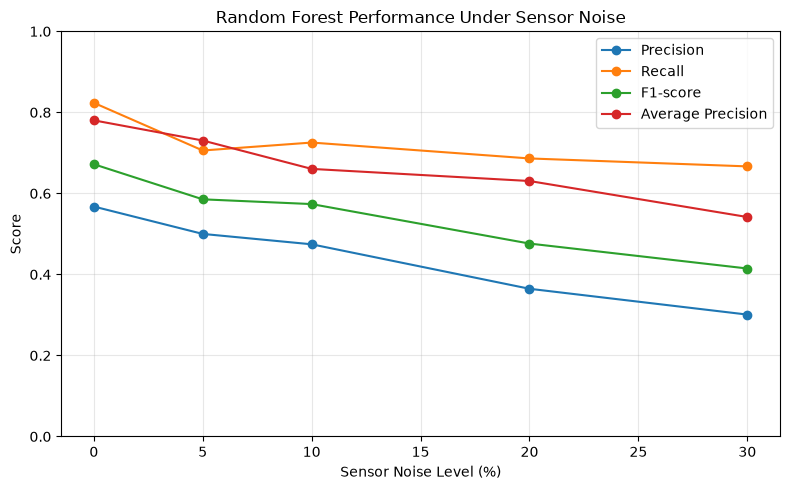

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["Average precision"],
    marker="o",
    label="Average Precision"
)

ax.set_xlabel("Sensor Noise Level (%)")
ax.set_ylabel("Score")
ax.set_title(
    "Random Forest Performance Under Sensor Noise"
)

ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "sensor_noise_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Sensor-Noise Experiment Findings

The results show that the selected Random Forest becomes progressively less
reliable as sensor measurement noise increases.

Under clean conditions, the model achieved a recall of 82.35%, an F1-score
of 67.20%, and an average precision of 78.03%.

At the highest tested noise level of 30%, recall decreased to 66.67%, the
F1-score decreased to 41.46%, and average precision decreased to 54.17%.

Precision showed a particularly large reduction, decreasing from 56.76% on
clean data to 30.09% at 30% sensor noise. This indicates that increasing
measurement corruption causes the model to generate substantially more false
failure warnings.

Although recall does not decrease monotonically at every individual noise
level, the overall trend across the experiment is downward. Small local
variations are expected because the simulated measurement errors are random.

The results demonstrate that the clean-trained Random Forest is sensitive to
sensor measurement corruption. This suggests that sensor quality and
measurement reliability are important considerations when deploying
machine-learning-based predictive-maintenance systems.

In [22]:
noise_results_path = (
    project_root
    / "results"
    / "sensor_noise_results.csv"
)

noise_results_df.to_csv(
    noise_results_path,
    index=False
)

print("Sensor-noise results saved to:")
print(noise_results_path)

Sensor-noise results saved to:
c:\Users\aacaa\Documents\reliable-machine-failure-prediction\results\sensor_noise_results.csv


## 7. Experiment 2 - Missing Sensor Measurements

Industrial sensor systems may occasionally produce missing measurements.

A sensor may temporarily fail, lose communication, or return an invalid value.
For example, a torque, temperature, or rotational-speed measurement may be
unavailable even though the machine is still operating.

In this experiment, controlled percentages of numerical sensor measurements
will be removed from the test set.

The same trained Random Forest model and the same decision threshold of 0.20
will be kept fixed.

The purpose of this experiment is to investigate how prediction performance
changes when some sensor information is unavailable.

In [23]:
def add_missing_sensor_values(
    X_data,
    missing_level,
    numeric_features,
    random_state=RANDOM_STATE
):
    missing_data = X_data.copy()

    rng = np.random.default_rng(random_state)

    random_values = rng.random(
        size=(
            len(X_data),
            len(numeric_features)
        )
    )

    missing_mask = (
        random_values < missing_level
    )

    missing_data.loc[
        :,
        numeric_features
    ] = missing_data[
        numeric_features
    ].mask(missing_mask)

    return missing_data


print("Missing-sensor function created successfully.")

Missing-sensor function created successfully.


In [26]:
X_test_missing_10 = X_test.copy()

# Convert numerical sensor columns to float
# so that they can store NaN missing values
X_test_missing_10[
    numeric_sensor_features
] = X_test_missing_10[
    numeric_sensor_features
].astype(float)

rng = np.random.default_rng(RANDOM_STATE)

random_values = rng.random(
    size=(
        len(X_test_missing_10),
        len(numeric_sensor_features)
    )
)

missing_mask = random_values < 0.10

X_test_missing_10[
    numeric_sensor_features
] = X_test_missing_10[
    numeric_sensor_features
].mask(missing_mask)

print("10% missing-data test set created successfully.")

print(
    "Total missing sensor values:",
    X_test_missing_10[numeric_sensor_features]
    .isna()
    .sum()
    .sum()
)

10% missing-data test set created successfully.
Total missing sensor values: 740


In [27]:
missing_comparison = pd.DataFrame({
    "Air temperature": X_test_missing_10["Air temperature"].head(10).values,
    "Process temperature": X_test_missing_10["Process temperature"].head(10).values,
    "Rotational speed": X_test_missing_10["Rotational speed"].head(10).values,
    "Torque": X_test_missing_10["Torque"].head(10).values,
    "Tool wear": X_test_missing_10["Tool wear"].head(10).values
})

display(missing_comparison)

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,298.1,309.0,1557.0,36.0,NaN
1,297.7,308.5,1559.0,35.2,127.0
2,301.5,309.8,1549.0,38.5,81.0
3,298.0,308.7,NaN,48.2,204.0
4,298.3,308.9,1708.0,28.0,42.0
5,300.8,311.8,NaN,43.4,223.0
6,299.1,308.5,1592.0,34.2,153.0
7,302.3,310.9,1545.0,36.7,18.0
8,298.0,309.2,1527.0,32.4,99.0
9,302.3,311.5,1316.0,47.2,4.0


### Handling Missing Sensor Values

The selected Random Forest was trained using complete sensor measurements.

Before evaluating corrupted test data containing missing values, the missing
numerical measurements must be replaced using values learned from the
training data.

Median imputation is used for the numerical sensor features.

The median is calculated only from the training set and then applied to the
corrupted test set. This avoids data leakage and provides a simple,
robust way to handle missing sensor measurements.

In [28]:
training_medians = X_train[
    numeric_sensor_features
].median()

print("Training-set medians:")
display(training_medians)

X_test_missing_10_filled = (
    X_test_missing_10.copy()
)

X_test_missing_10_filled[
    numeric_sensor_features
] = X_test_missing_10_filled[
    numeric_sensor_features
].fillna(training_medians)

print(
    "\nRemaining missing sensor values:",
    X_test_missing_10_filled[
        numeric_sensor_features
    ].isna().sum().sum()
)

Training-set medians:


Air temperature         300.1
Process temperature     310.1
Rotational speed       1504.0
Torque                   40.1
Tool wear               107.0
dtype: float64


Remaining missing sensor values: 0


In [29]:
X_test_missing_10_tree = tree_preprocessor.transform(
    X_test_missing_10_filled
)

print(
    "Filled missing-data test transformed shape:",
    X_test_missing_10_tree.shape
)

Filled missing-data test transformed shape: (1500, 8)


In [30]:
missing_10_probabilities = random_forest_model.predict_proba(
    X_test_missing_10_tree
)[:, 1]

missing_10_predictions = (
    missing_10_probabilities >= selected_threshold
).astype(int)

missing_10_accuracy = accuracy_score(
    y_test,
    missing_10_predictions
)

missing_10_precision = precision_score(
    y_test,
    missing_10_predictions,
    zero_division=0
)

missing_10_recall = recall_score(
    y_test,
    missing_10_predictions
)

missing_10_f1 = f1_score(
    y_test,
    missing_10_predictions
)

missing_10_ap = average_precision_score(
    y_test,
    missing_10_probabilities
)

missing_10_matrix = confusion_matrix(
    y_test,
    missing_10_predictions
)

print("10% missing-sensor results:")
print("Accuracy:", round(missing_10_accuracy, 4))
print("Precision:", round(missing_10_precision, 4))
print("Recall:", round(missing_10_recall, 4))
print("F1-score:", round(missing_10_f1, 4))
print("Average precision:", round(missing_10_ap, 4))

print("\nConfusion matrix:")
print(missing_10_matrix)

10% missing-sensor results:
Accuracy: 0.9693
Precision: 0.5362
Recall: 0.7255
F1-score: 0.6167
Average precision: 0.6976

Confusion matrix:
[[1417   32]
 [  14   37]]


In [31]:
clean_vs_missing_10 = pd.DataFrame(
    {
        "Accuracy": [
            clean_accuracy,
            missing_10_accuracy
        ],
        "Precision": [
            clean_precision,
            missing_10_precision
        ],
        "Recall": [
            clean_recall,
            missing_10_recall
        ],
        "F1-score": [
            clean_f1,
            missing_10_f1
        ],
        "Average precision": [
            clean_ap,
            missing_10_ap
        ]
    },
    index=[
        "Clean",
        "10% missing"
    ]
)

display(clean_vs_missing_10.round(4))

,Accuracy,Precision,Recall,F1-score,Average precision
Clean,0.9727,0.5676,0.8235,0.6720,0.7803
10% missing,0.9693,0.5362,0.7255,0.6167,0.6976


### Multiple Missing-Data Levels

To evaluate robustness systematically, the selected Random Forest is tested
under several levels of missing numerical sensor measurements.

The same test samples, trained model, preprocessing pipeline, target labels,
median-imputation strategy, and decision threshold are kept fixed.

Only the percentage of missing sensor measurements is changed.

This allows the effect of increasing sensor-data loss on prediction
performance to be measured directly.

In [32]:
missing_levels = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]

missing_results = []

for missing_level in missing_levels:

    # Start from a clean copy of the test set
    X_missing = X_test.copy()

    # Convert numerical sensor columns to float
    X_missing[numeric_sensor_features] = (
        X_missing[numeric_sensor_features]
        .astype(float)
    )

    # Create reproducible missing-value pattern
    rng = np.random.default_rng(RANDOM_STATE)

    random_values = rng.random(
        size=(
            len(X_missing),
            len(numeric_sensor_features)
        )
    )

    missing_mask = (
        random_values < missing_level
    )

    # Apply missing values
    X_missing[numeric_sensor_features] = (
        X_missing[numeric_sensor_features]
        .mask(missing_mask)
    )

    # Fill missing values using medians learned from training data
    X_missing[numeric_sensor_features] = (
        X_missing[numeric_sensor_features]
        .fillna(training_medians)
    )

    # Apply the already-fitted Random Forest preprocessing
    X_missing_tree = tree_preprocessor.transform(
        X_missing
    )

    # Predict failure probabilities
    probabilities = random_forest_model.predict_proba(
        X_missing_tree
    )[:, 1]

    # Apply the fixed threshold
    predictions = (
        probabilities >= selected_threshold
    ).astype(int)

    # Calculate evaluation metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    ap = average_precision_score(
        y_test,
        probabilities
    )

    missing_results.append(
        {
            "Missing level": missing_level,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Average precision": ap
        }
    )

missing_results_df = pd.DataFrame(
    missing_results
)

display(
    missing_results_df.round(4)
)

,Missing level,Accuracy,Precision,Recall,F1-score,Average precision
0,0.00,0.9727,0.5676,0.8235,0.6720,0.7803
1,0.05,0.9713,0.5571,0.7647,0.6446,0.7248
2,0.10,0.9693,0.5362,0.7255,0.6167,0.6976
3,0.20,0.9700,0.5517,0.6275,0.5872,0.6133
4,0.30,0.9687,0.5417,0.5098,0.5253,0.5432


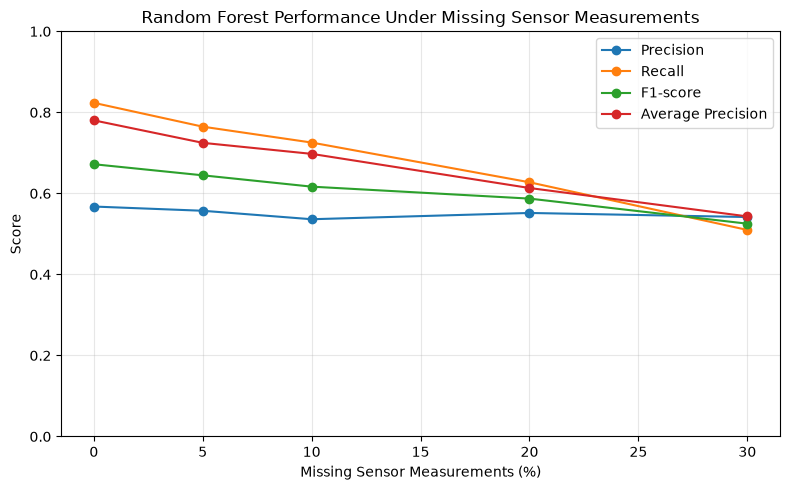

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    missing_results_df["Missing level"] * 100,
    missing_results_df["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    missing_results_df["Missing level"] * 100,
    missing_results_df["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    missing_results_df["Missing level"] * 100,
    missing_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

ax.plot(
    missing_results_df["Missing level"] * 100,
    missing_results_df["Average precision"],
    marker="o",
    label="Average Precision"
)

ax.set_xlabel("Missing Sensor Measurements (%)")
ax.set_ylabel("Score")

ax.set_title(
    "Random Forest Performance Under Missing Sensor Measurements"
)

ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "missing_data_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Missing-Data Experiment Findings

The results show that the Random Forest becomes less reliable as the
percentage of missing sensor measurements increases.

Under clean conditions, the model achieved a recall of 82.35%, an F1-score
of 67.20%, and an average precision of 78.03%.

When 30% of the numerical sensor measurements were missing and replaced
using training-set median values, recall decreased to 50.98%, the F1-score
decreased to 52.53%, and average precision decreased to 54.32%.

The reduction in recall is particularly important because it means that the
model misses more real machine failures when sensor information is
unavailable.

Accuracy remained high throughout the experiment, decreasing only from
97.27% to 96.87%. However, this does not indicate that failure detection
remained equally reliable. The relatively stable accuracy is largely caused
by the strong class imbalance, where healthy machines represent the majority
of the dataset.

These results demonstrate that missing sensor measurements can substantially
reduce failure-detection capability even when overall accuracy remains high.

In [34]:
missing_results_path = (
    project_root
    / "results"
    / "missing_data_results.csv"
)

missing_results_df.to_csv(
    missing_results_path,
    index=False
)

print("Missing-data results saved to:")
print(missing_results_path)

Missing-data results saved to:
c:\Users\aacaa\Documents\reliable-machine-failure-prediction\results\missing_data_results.csv


## 8. Experiment 3 - Limited Training Data

In real predictive-maintenance projects, large amounts of labelled failure
data may not always be available.

Collecting machine-failure examples can be difficult because failures are
relatively rare, expensive, or time-consuming to observe.

In this experiment, the Random Forest is trained using progressively smaller
fractions of the original training set.

The validation and test sets remain unchanged.

The purpose of this experiment is to measure how strongly model performance
depends on the amount of labelled training data available.

In [37]:
training_fractions = [
    0.20,
    0.40,
    0.60,
    0.80,
    1.00
]

print("Training fractions to test:")

for fraction in training_fractions:
    print(f"{int(fraction * 100)}%")

Training fractions to test:
20%
40%
60%
80%
100%


In [39]:
from sklearn.model_selection import train_test_split

limited_training_sets = {}

for fraction in training_fractions:

    if fraction == 1.00:
        X_subset = X_train.copy()
        y_subset = y_train.copy()

    else:
        X_subset, _, y_subset, _ = train_test_split(
            X_train,
            y_train,
            train_size=fraction,
            stratify=y_train,
            random_state=RANDOM_STATE
        )

    limited_training_sets[fraction] = (
        X_subset,
        y_subset
    )

    print(
        f"{int(fraction * 100)}% training data:"
        f" {len(X_subset)} samples,"
        f" {int(y_subset.sum())} failures"
    )

20% training data: 1400 samples, 47 failures
40% training data: 2800 samples, 95 failures
60% training data: 4200 samples, 142 failures
80% training data: 5600 samples, 190 failures
100% training data: 7000 samples, 237 failures


In [40]:
limited_training_results = []

for fraction in training_fractions:

    X_subset, y_subset = limited_training_sets[fraction]

    # Create a fresh preprocessing pipeline
    subset_preprocessor = create_preprocessor(
        scale_numeric=False
    )

    # Fit preprocessing only on this training subset
    X_subset_tree = subset_preprocessor.fit_transform(
        X_subset
    )

    # Apply the same fitted preprocessing to the unchanged clean test set
    X_test_subset_tree = subset_preprocessor.transform(
        X_test
    )

    # Train a fresh Random Forest using only this subset
    subset_model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    subset_model.fit(
        X_subset_tree,
        y_subset
    )

    # Get failure probabilities on the same clean test set
    probabilities = subset_model.predict_proba(
        X_test_subset_tree
    )[:, 1]

    # Apply the same fixed threshold
    predictions = (
        probabilities >= selected_threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    ap = average_precision_score(
        y_test,
        probabilities
    )

    limited_training_results.append(
        {
            "Training fraction": fraction,
            "Training samples": len(X_subset),
            "Failure samples": int(y_subset.sum()),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Average precision": ap
        }
    )

limited_training_results_df = pd.DataFrame(
    limited_training_results
)

display(
    limited_training_results_df.round(4)
)

,Training fraction,Training samples,Failure samples,Accuracy,Precision,Recall,F1-score,Average precision
0,0.2,1400,47,0.9673,0.5152,0.6667,0.5812,0.6546
1,0.4,2800,95,0.9660,0.5000,0.8039,0.6165,0.6978
2,0.6,4200,142,0.9700,0.5385,0.8235,0.6512,0.7484
3,0.8,5600,190,0.9687,0.5270,0.7647,0.6240,0.7781
4,1.0,7000,237,0.9727,0.5676,0.8235,0.6720,0.7803


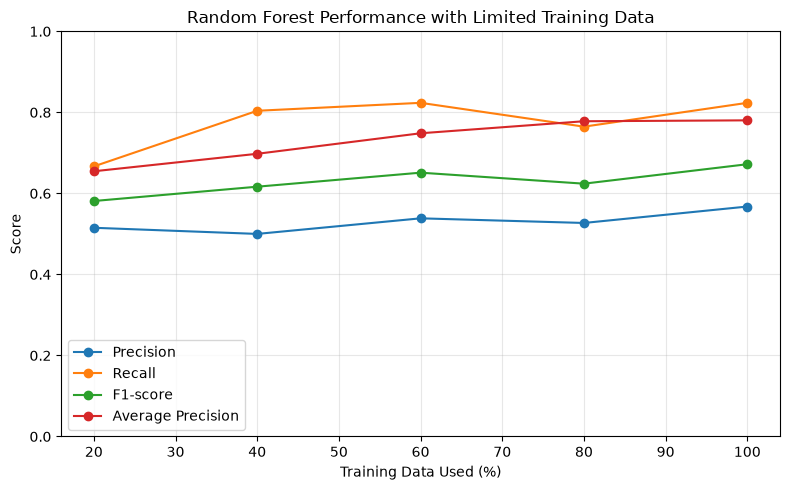

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    limited_training_results_df["Training fraction"] * 100,
    limited_training_results_df["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    limited_training_results_df["Training fraction"] * 100,
    limited_training_results_df["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    limited_training_results_df["Training fraction"] * 100,
    limited_training_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

ax.plot(
    limited_training_results_df["Training fraction"] * 100,
    limited_training_results_df["Average precision"],
    marker="o",
    label="Average Precision"
)

ax.set_xlabel("Training Data Used (%)")
ax.set_ylabel("Score")
ax.set_title(
    "Random Forest Performance with Limited Training Data"
)

ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "limited_training_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Limited-Training-Data Experiment Findings

The results show that model performance is affected by the amount of labelled
training data available.

When only 20% of the original training data was used, the Random Forest
achieved a recall of 66.67%, an F1-score of 58.12%, and an average precision
of 65.46%.

As the amount of training data increased, overall performance generally
improved. Average precision increased steadily from 65.46% at 20% training
data to 78.03% when the full training set was used.

Recall improved strongly from 66.67% at 20% training data to 82.35% at 60%
and 100% training data.

Although recall did not increase monotonically at every training fraction,
the overall results show that larger labelled training sets provide more
reliable failure prediction.

These findings indicate that limited labelled failure data can reduce model
reliability, especially when the available training set contains relatively
few failure examples.

In [42]:
limited_training_results_path = (
    project_root
    / "results"
    / "limited_training_results.csv"
)

limited_training_results_df.to_csv(
    limited_training_results_path,
    index=False
)

print("Limited-training-data results saved to:")
print(limited_training_results_path)

Limited-training-data results saved to:
c:\Users\aacaa\Documents\reliable-machine-failure-prediction\results\limited_training_results.csv


## 9. Overall Robustness Comparison

The three robustness experiments evaluate different practical limitations of
machine-failure prediction:

1. Sensor measurement noise
2. Missing sensor measurements
3. Limited labelled training data

The clean-data Random Forest serves as the common reference system.

This section compares the main performance changes across all experiments in
order to identify which conditions have the strongest effect on failure
prediction reliability.

In [43]:
overall_robustness_summary = pd.DataFrame(
    {
        "Condition": [
            "Clean baseline",
            "30% sensor noise",
            "30% missing data",
            "20% training data"
        ],
        "Precision": [
            clean_precision,
            noise_results_df.loc[
                noise_results_df["Noise level"] == 0.30,
                "Precision"
            ].iloc[0],
            missing_results_df.loc[
                missing_results_df["Missing level"] == 0.30,
                "Precision"
            ].iloc[0],
            limited_training_results_df.loc[
                limited_training_results_df["Training fraction"] == 0.20,
                "Precision"
            ].iloc[0]
        ],
        "Recall": [
            clean_recall,
            noise_results_df.loc[
                noise_results_df["Noise level"] == 0.30,
                "Recall"
            ].iloc[0],
            missing_results_df.loc[
                missing_results_df["Missing level"] == 0.30,
                "Recall"
            ].iloc[0],
            limited_training_results_df.loc[
                limited_training_results_df["Training fraction"] == 0.20,
                "Recall"
            ].iloc[0]
        ],
        "F1-score": [
            clean_f1,
            noise_results_df.loc[
                noise_results_df["Noise level"] == 0.30,
                "F1-score"
            ].iloc[0],
            missing_results_df.loc[
                missing_results_df["Missing level"] == 0.30,
                "F1-score"
            ].iloc[0],
            limited_training_results_df.loc[
                limited_training_results_df["Training fraction"] == 0.20,
                "F1-score"
            ].iloc[0]
        ],
        "Average precision": [
            clean_ap,
            noise_results_df.loc[
                noise_results_df["Noise level"] == 0.30,
                "Average precision"
            ].iloc[0],
            missing_results_df.loc[
                missing_results_df["Missing level"] == 0.30,
                "Average precision"
            ].iloc[0],
            limited_training_results_df.loc[
                limited_training_results_df["Training fraction"] == 0.20,
                "Average precision"
            ].iloc[0]
        ]
    }
)

display(overall_robustness_summary.round(4))

,Condition,Precision,Recall,F1-score,Average precision
0,Clean baseline,0.5676,0.8235,0.6720,0.7803
1,30% sensor noise,0.3009,0.6667,0.4146,0.5417
2,30% missing data,0.5417,0.5098,0.5253,0.5432
3,20% training data,0.5152,0.6667,0.5812,0.6546


### Overall Robustness Findings

The three robustness experiments show that the selected Random Forest is
affected differently by sensor corruption and limited training data.

Under clean conditions, the model achieved a recall of 82.35%, an F1-score
of 67.20%, and an average precision of 78.03%.

At 30% sensor noise, recall decreased to 66.67% and the F1-score decreased
to 41.46%. This shows that noisy sensor measurements substantially increase
prediction errors and false failure warnings.

At 30% missing sensor measurements, recall decreased further to 50.98%.
This was the largest reduction in failure-detection capability among the
tested robustness conditions.

When the model was trained using only 20% of the original training data,
recall decreased to 66.67% and average precision decreased to 65.46%.
This indicates that limited labelled training data also reduces model
reliability.

Overall, missing sensor measurements had the strongest negative effect on
failure recall, while sensor noise produced the largest reduction in
precision and F1-score.

These findings show that reliable predictive-maintenance deployment depends
not only on model selection, but also on sensor-data quality, sensor
availability, and sufficient labelled training data.

In [44]:
overall_summary_path = (
    project_root
    / "results"
    / "overall_robustness_summary.csv"
)

overall_robustness_summary.to_csv(
    overall_summary_path,
    index=False
)

print("Overall robustness summary saved to:")
print(overall_summary_path)

Overall robustness summary saved to:
c:\Users\aacaa\Documents\reliable-machine-failure-prediction\results\overall_robustness_summary.csv


## 10. Robustness Experiment Conclusion

This notebook evaluated the selected Random Forest machine-failure
prediction system under three practical robustness conditions:

1. Sensor measurement noise
2. Missing sensor measurements
3. Limited labelled training data

The clean-data reference achieved a recall of 82.35%, an F1-score of
67.20%, and an average precision of 78.03%.

Increasing sensor noise reduced overall prediction reliability, with the
largest tested noise level producing substantial decreases in precision,
recall, F1-score, and average precision.

Missing sensor measurements had the strongest effect on failure recall.
At 30% missing measurements, recall decreased to 50.98%, showing that the
model missed nearly half of the actual failures.

Limited training data also reduced performance. When only 20% of the
original training data was used, recall decreased to 66.67% and average
precision decreased to 65.46%.

These experiments demonstrate that strong clean-data performance alone is
not sufficient to guarantee reliable predictive-maintenance performance in
real operating conditions.

Sensor quality, sensor availability, and the quantity of labelled training
data all have important effects on model reliability.

The next stage of the project will investigate model explainability using
feature importance and SHAP analysis to understand which machine
measurements contribute most strongly to failure predictions.